# Round 3 — The Options Round

Twelve products: two spot instruments (`HYDROGEL_PACK` ±200, `VELVETFRUIT_EXTRACT` ±200) and
ten call vouchers `VEV_4000` … `VEV_6500` (±300 each). The first scored round of Phase 2.

**Scored 5,841 — the lowest of the five rounds. Ten of the twelve products never traded.**

This notebook works out what the market was, then examines why nothing traded and what that
was worth.

Summary: [`rounds/03/README.md`](../rounds/03/README.md).
Specification: [`rounds/03/answer.md`](../rounds/03/answer.md).

In [1]:
import sys, warnings
sys.path.insert(0, "../tools")
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import figures as F
import product_props as pp
import prosperity_review as pr
from benchmarks import split_flow_by_aggressor

F.style()
DATA, RND, DAYS = "../data/round3", 3, [0, 1, 2]
PACK, FRUIT = "HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"
STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VEV = [f"VEV_{k}" for k in STRIKES]

px = {d: pp.load(DATA, RND, d)[0] for d in DAYS}
tr = {d: pp.load(DATA, RND, d)[1] for d in DAYS}

def sub(f, p): return f[f["product"] == p].reset_index(drop=True)
def mid(f, p):
    g = f[f["product"] == p].set_index("timestamp")
    return ((g["bid_price_1"] + g["ask_price_1"]) / 2).ffill().bfill()

print("products:", px[0]["product"].nunique())

products: 12


## 1. What the vouchers are

A call struck at $K$ on underlying $S$ must satisfy $\max(S-K,0) \le C \le S$, and its time
value $C - \max(S-K,0)$ must vanish deep in the money and peak at the money.

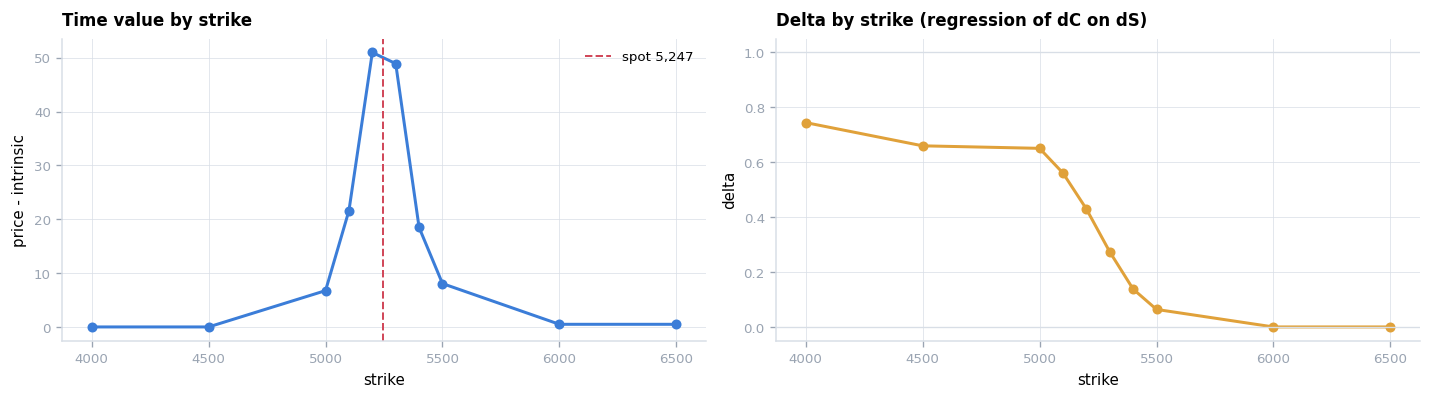

,K,mean price,intrinsic,time value,ticks above S
0,4000,1246.52,1246.51,0.01,0.0%
1,4500,746.52,746.51,0.01,0.0%
2,5000,253.26,246.51,6.75,0.0%
3,5100,168.11,146.51,21.60,0.0%
4,5200,97.47,46.51,50.96,0.0%
5,5300,48.89,0.00,48.89,0.0%
6,5400,18.47,0.00,18.47,0.0%
7,5500,8.06,0.00,8.06,0.0%
8,6000,0.50,0.00,0.50,0.0%
9,6500,0.50,0.00,0.50,0.0%


In [2]:
S = mid(px[0], FRUIT)
rows = []
for k in STRIKES:
    C = mid(px[0], f"VEV_{k}")
    i = S.index.intersection(C.index)
    intr = np.maximum(S[i] - k, 0)
    rows.append({"K": k, "mean price": round(C[i].mean(), 2),
                 "intrinsic": round(intr.mean(), 2),
                 "time value": round((C[i] - intr).mean(), 2),
                 "ticks above S": f"{(C[i] > S[i]).mean():.1%}"})
tv = pd.DataFrame(rows)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].plot(tv["K"], tv["time value"], "o-", lw=1.8, ms=5, color=F.BLUE)
ax[0].axvline(S.mean(), color=F.HI, ls="--", lw=1.2, label=f"spot {S.mean():,.0f}")
F.finish(ax[0], "Time value by strike", "strike", "price - intrinsic", legend=True)

deltas = []
for k in STRIKES:
    C = mid(px[0], f"VEV_{k}"); dS = S.diff(); dC = C.diff()
    j = dS.dropna().index.intersection(dC.dropna().index)
    deltas.append(np.polyfit(dS[j], dC[j], 1)[0])
ax[1].plot(STRIKES, deltas, "o-", lw=1.8, ms=5, color=F.ACCENT)
ax[1].axhline(1, color=F.GRID, lw=.8); ax[1].axhline(0, color=F.GRID, lw=.8)
F.finish(ax[1], "Delta by strike (regression of dC on dS)", "strike", "delta")
F.save(fig, "r3_option_shape")
tv

Time value is **0.01** at strikes 4000 and 4500, peaks near 51 at the money, and returns to
0.5 far out. Delta falls monotonically from 0.74 to 0.00. These are call options.

**The deep in-the-money strikes carry no time value at all**, so their price is an identity:

$$C_t = S_t - K \qquad (K \in \{4000, 4500\})$$

No volatility, no expiry, nothing to estimate.

## 2. Is there static arbitrage across the chain?

Checked on **executable** prices — a violation at the midpoint cannot be monetised.

* monotonicity: $C(K_1) \ge C(K_2)$ for $K_1 < K_2$
* convexity: $C(K_1) - 2C(K_2) + C(K_3) \ge 0$ for equally spaced strikes
* bounds: $\max(S-K,0) \le C \le S$

In [3]:
for d in DAYS:
    g = {p: px[d][px[d]["product"] == p].set_index("timestamp") for p in [FRUIT] + VEV}
    ts = g[FRUIT].index
    v1 = sum(int((g[f"VEV_{STRIKES[i]}"]["ask_price_1"].reindex(ts)
                  < g[f"VEV_{STRIKES[i+1]}"]["bid_price_1"].reindex(ts)).sum())
             for i in range(len(STRIKES) - 1))
    v2 = 0
    for i in range(len(STRIKES) - 2):
        k1, k2, k3 = STRIKES[i:i+3]
        if k1 + k3 != 2 * k2: continue
        v2 += int(((g[f"VEV_{k1}"]["ask_price_1"].reindex(ts)
                    + g[f"VEV_{k3}"]["ask_price_1"].reindex(ts)
                    - 2 * g[f"VEV_{k2}"]["bid_price_1"].reindex(ts)) < 0).sum())
    print(f"day {d}:  monotonicity violations {v1}   convexity violations {v2}")

day 0:  monotonicity violations 0   convexity violations 0
day 1:  monotonicity violations 0   convexity violations 0
day 2:  monotonicity violations 0   convexity violations 0


**Zero on all three days. The chain is internally consistent — there is no free money across
strikes.**

## 3. Are the spot products tradeable directionally?

Same estimators as Rounds 1 and 2, so the numbers are directly comparable to ASH.

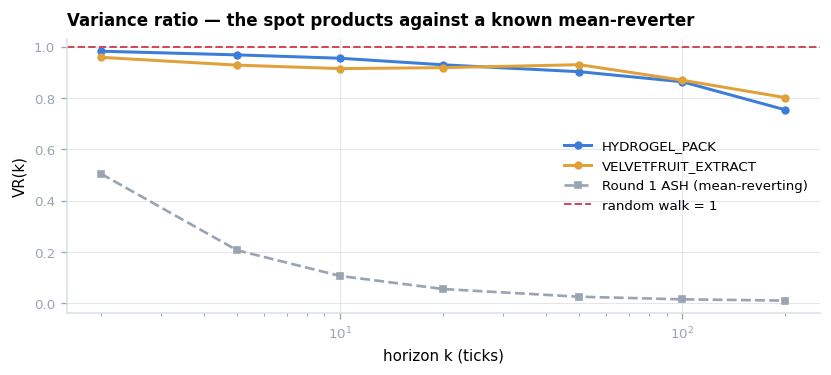

,product,day,slope,VR(50),VR(200)
0,HYDROGEL_PACK,0.0,-0.0028,0.845,0.714
1,HYDROGEL_PACK,1.0,-0.0013,0.961,0.781
2,HYDROGEL_PACK,2.0,-0.0019,0.901,0.766
3,VELVETFRUIT_EXTRACT,0.0,-0.0026,0.950,0.734
4,VELVETFRUIT_EXTRACT,1.0,-0.0022,1.030,0.935
5,VELVETFRUIT_EXTRACT,2.0,-0.0014,0.809,0.735


In [4]:
rows = []
for prod, nm in [(PACK, "HYDROGEL_PACK"), (FRUIT, "VELVETFRUIT_EXTRACT")]:
    t = pp.ou_check(DATA, RND, DAYS, prod)
    for _, r in t.iterrows():
        rows.append({"product": nm, "day": r["day"], "slope": r["beta"],
                     "VR(50)": r["VR(50)"], "VR(200)": r["VR(200)"]})
cmp = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 3.2))
ks = [2, 5, 10, 20, 50, 100, 200]
for prod, nm, col in [(PACK, "HYDROGEL_PACK", F.BLUE), (FRUIT, "VELVETFRUIT_EXTRACT", F.ACCENT)]:
    v = [np.mean([pp.vr(pp.largest_level_mid(sub(px[d], prod)).values, k) for d in DAYS]) for k in ks]
    ax.plot(ks, v, "o-", lw=1.8, ms=4, color=col, label=nm)
ash = [0.505, 0.207, 0.107, 0.056, 0.026, 0.016, 0.011]
ax.plot(ks, ash, "s--", lw=1.6, ms=4, color=F.GREY, label="Round 1 ASH (mean-reverting)")
ax.axhline(1, color=F.HI, ls="--", lw=1.2, label="random walk = 1")
ax.set_xscale("log")
F.finish(ax, "Variance ratio — the spot products against a known mean-reverter",
         "horizon k (ticks)", "VR(k)", legend=True)
F.save(fig, "r3_spot_vr")
cmp

**Both spot products sit near the random-walk line at every horizon**, with reversion slopes
around −0.002. Round 1's ASH, on the same axes, sits an order of magnitude lower.

**Neither PACK nor FRUIT can be traded directionally.** The submitted algorithm applied a
mean-reversion rule with a threshold of ±15 to both.

## 4. The one thing in this round that does revert

Define the basis of a deep-ITM voucher against its identity value:

$$b_t = C_t - (S_t - K)$$

Its equilibrium is not estimated — §1 shows it is the time value, and that is 0.01.

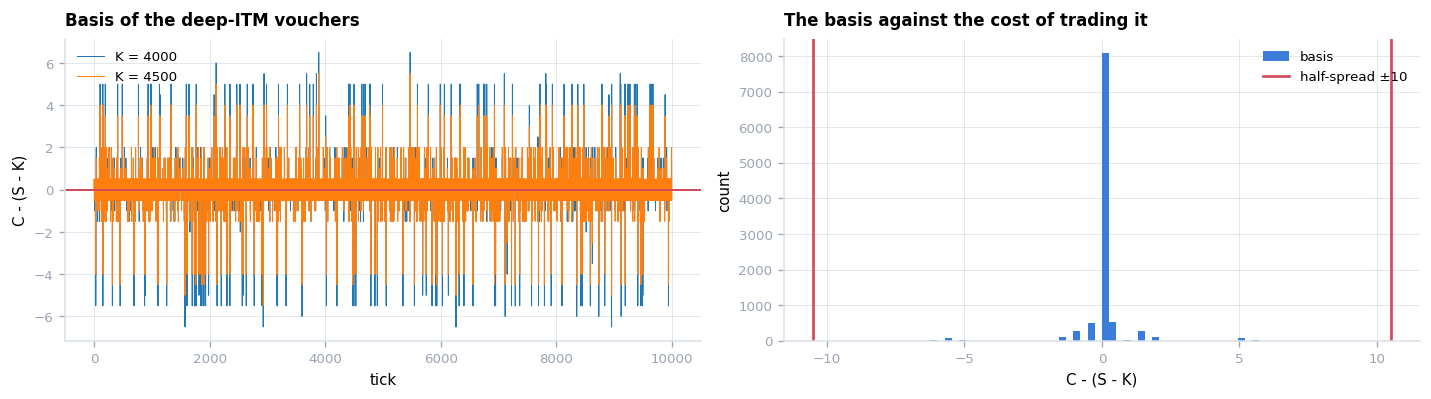

,K,mean,sd,VR(50),VR(200)
0,4000,0.01,0.82,0.02,0.0050
1,4500,0.01,0.75,0.02,0.0050
2,5000,6.75,1.35,0.03,0.0132


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
rows = []
for k in (4000, 4500, 5000):
    b = (mid(px[0], f"VEV_{k}") - (mid(px[0], FRUIT) - k)).dropna()
    rows.append({"K": k, "mean": round(b.mean(), 2), "sd": round(b.std(), 2),
                 "VR(50)": round(pp.vr(b.values, 50), 3),
                 "VR(200)": round(pp.vr(b.values, 200), 4)})
    if k != 5000:
        ax[0].plot(b.values, lw=.6, label=f"K = {k}")
sp4000 = (px[0][px[0]["product"] == "VEV_4000"]["ask_price_1"]
          - px[0][px[0]["product"] == "VEV_4000"]["bid_price_1"]).median()
ax[0].axhline(0, color=F.HI, lw=1.2)
F.finish(ax[0], "Basis of the deep-ITM vouchers", "tick", "C - (S - K)", legend=True)

b = (mid(px[0], "VEV_4000") - (mid(px[0], FRUIT) - 4000)).dropna()
ax[1].hist(b.values, bins=50, color=F.BLUE, label="basis")
ax[1].axvline(-sp4000/2, color=F.HI, lw=1.6)
ax[1].axvline(sp4000/2, color=F.HI, lw=1.6, label=f"half-spread ±{sp4000/2:.0f}")
F.finish(ax[1], "The basis against the cost of trading it", "C - (S - K)", "count", legend=True)
F.save(fig, "r3_basis")
pd.DataFrame(rows)

**VR(200) = 0.005 — a hundred and fifty times stronger reversion than the underlying's 0.73,
with an equilibrium given by an identity rather than a fit.**

> **The instruments have no structure; the relationship between them does.**

**But it cannot be traded directly.** The basis has a standard deviation of 0.82 while
`VEV_4000` quotes a 21-tick spread: the entire signal fits inside half the spread. The right
panel shows the whole distribution sitting between the two crossing costs.

Its use is as a fair-value estimator for quoting — more accurate than anything requiring a
volatility estimate, because the estimation error alone would exceed 0.82.

## 5. Where the money is — and why the obvious metric misleads

A round-trip measure (the smaller of the two flow directions) reports zero for eight of the
ten vouchers. That measure assumes earning requires buying *and* selling the same instrument.
Option market making does not: the position is hedged in the underlying.

Splitting the flow by side shows why it matters.

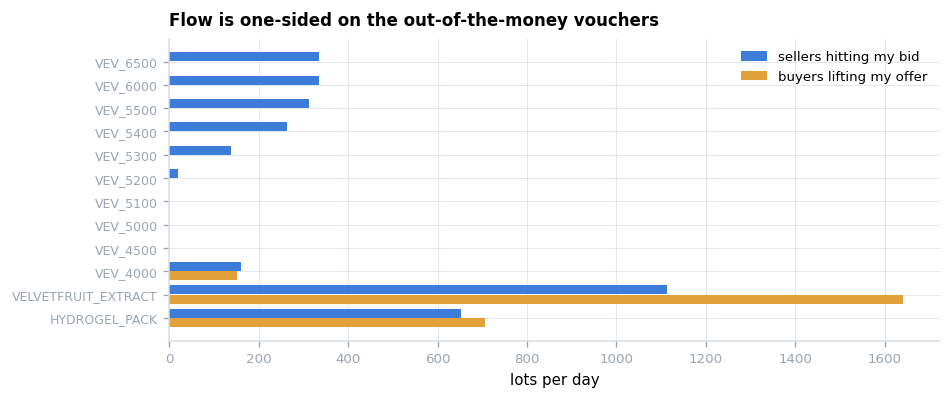

,product,sellers hitting my bid,buyers lifting my offer,min of the two,spread
0,HYDROGEL_PACK,653,706,653,16.0
1,VELVETFRUIT_EXTRACT,1114,1641,1114,5.0
2,VEV_4000,161,151,151,21.0
3,VEV_4500,0,0,0,16.0
4,VEV_5000,0,0,0,6.0
5,VEV_5100,0,0,0,4.0
6,VEV_5200,20,0,0,3.0
7,VEV_5300,138,0,0,2.0
8,VEV_5400,262,0,0,1.0
9,VEV_5500,312,0,0,1.0


In [6]:
rows = []
for prod in [PACK, FRUIT] + VEV:
    tb = ta = 0.0; sp = []
    for d in DAYS:
        f = split_flow_by_aggressor(px[d], tr[d], prod)
        tb += f["to_my_bid"].sum(); ta += f["to_my_ask"].sum()
        g = sub(px[d], prod)
        sp.append((g["ask_price_1"] - g["bid_price_1"]).median())
    rows.append({"product": prod, "sellers hitting my bid": int(tb/3),
                 "buyers lifting my offer": int(ta/3),
                 "min of the two": int(min(tb, ta)/3), "spread": float(np.nanmedian(sp))})
flow = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 3.4))
i = np.arange(len(flow))
ax.barh(i + .2, flow["sellers hitting my bid"], .38, color=F.BLUE, label="sellers hitting my bid")
ax.barh(i - .2, flow["buyers lifting my offer"], .38, color=F.ACCENT, label="buyers lifting my offer")
ax.set_yticks(i); ax.set_yticklabels(flow["product"], fontsize=7.5)
F.finish(ax, "Flow is one-sided on the out-of-the-money vouchers", "lots per day", "", legend=True)
F.save(fig, "r3_flow_sides")
flow

**On every out-of-the-money voucher the flow runs one way: participants sell, nobody buys.**
A round-trip metric scores all of them zero. What is actually available is a one-sided
inventory build, hedged in FRUIT.

So price the opportunity properly: for each voucher, the edge per lot is the distance from
fair to the price at which the fill occurs, times the flow that arrives there.

One correction the data forces: on a one-tick spread there is no inside to quote. Posting at
`best_bid + 1` would be lifting the offer, i.e. paying 1 for something worth 0.5. Where the
spread is 1 the only available quote is the touch itself.

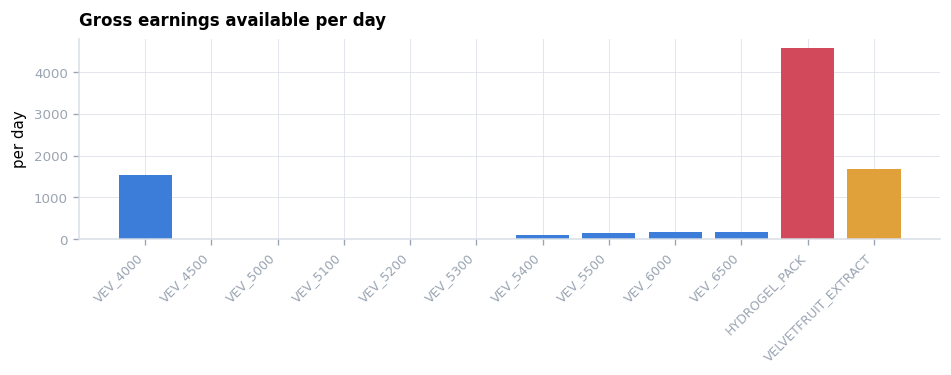

all ten vouchers: 2,104/day    PACK alone: 4,571/day


,voucher,flow/day,spread,edge/lot,gross/day,delta
0,VEV_4000,161,21.0,9.45,1528,0.745
1,VEV_4500,0,16.0,0.00,0,0.662
2,VEV_5000,0,6.0,0.00,0,0.653
3,VEV_5100,0,4.0,0.00,0,0.577
4,VEV_5200,20,3.0,0.00,0,0.437
5,VEV_5300,138,2.0,0.01,2,0.273
6,VEV_5400,262,1.0,0.37,97,0.129
7,VEV_5500,312,1.0,0.46,143,0.055
8,VEV_6000,334,1.0,0.50,167,0.000
9,VEV_6500,334,1.0,0.50,167,0.000


In [7]:
rows = []
for k in STRIKES:
    ed = fl = 0.0; dl = []; sp = []
    for d in DAYS:
        g = px[d][px[d]["product"] == f"VEV_{k}"].set_index("timestamp")
        Sm = mid(px[d], FRUIT)
        fair = ((g["bid_price_1"] + g["ask_price_1"]) / 2).ffill().bfill()
        s = g["ask_price_1"] - g["bid_price_1"]
        my_bid = np.where(s > 1, g["bid_price_1"] + 1, g["bid_price_1"])
        w = split_flow_by_aggressor(px[d], tr[d], f"VEV_{k}")["to_my_bid"].reindex(fair.index).fillna(0)
        ed += float(((fair - my_bid) * w).sum()); fl += float(w.sum()); sp.append(s.median())
        dl.append(np.polyfit(Sm.diff().dropna(), fair.reindex(Sm.index).diff().dropna(), 1)[0])
    rows.append({"voucher": f"VEV_{k}", "flow/day": int(fl/3), "spread": float(np.nanmedian(sp)),
                 "edge/lot": round(ed/max(fl, 1), 2), "gross/day": int(ed/3),
                 "delta": round(float(np.mean(dl)), 3)})
v = pd.DataFrame(rows)

pack = int(flow.set_index("product").loc[PACK, "min of the two"] * (16 - 2) / 2)
fruit = int(flow.set_index("product").loc[FRUIT, "min of the two"] * (5 - 2) / 2)
fig, ax = plt.subplots(figsize=(8, 3.2))
lab = list(v["voucher"]) + ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]
val = list(v["gross/day"]) + [pack, fruit]
ax.bar(range(len(lab)), val, color=[F.BLUE]*len(v) + [F.HI, F.ACCENT])
ax.set_xticks(range(len(lab))); ax.set_xticklabels(lab, rotation=45, ha="right", fontsize=7.5)
F.finish(ax, "Gross earnings available per day", "", "per day")
F.save(fig, "r3_earnings")
print(f"all ten vouchers: {v['gross/day'].sum():,}/day    PACK alone: {pack:,}/day")
v

**All ten vouchers together are worth about 2,100 a day — less than half of `HYDROGEL_PACK`
alone.**

`VEV_4000` accounts for three quarters of the voucher total: it is the only one with both a
wide spread and real flow. The far out-of-the-money strikes pay 0.5 a lot on 334 lots, which
is real but small. The at-the-money strikes have **no flow at all** in the pre-round data.

> A rank-64 team's public write-up reports the at-the-money cluster carrying the bulk of their
> voucher PnL. That cannot come from intercepting flow, since there is none here. It would
> have to come from lifting mispriced resting quotes, which requires a volatility model to
> identify. **That mechanism is not tested in this notebook and is left open.**

## 6. Why nothing traded

The option leg is gated by

```python
if avg_abs_dev < IV_SCALPING_THR:   # 0.7
    continue
```

Extracting `avg_abs_dev` from the scored day by replaying the submitted source under
`sys.settrace`, and doing the same over the three pre-round days.

scored day           gate reached on  9990 ticks   max 0.4750   times above 0.7: 0


pre-round day 0      gate reached on  9990 ticks   max 0.4525   times above 0.7: 0


pre-round day 1      gate reached on  9990 ticks   max 0.5020   times above 0.7: 0


pre-round day 2      gate reached on  9990 ticks   max 0.4665   times above 0.7: 0


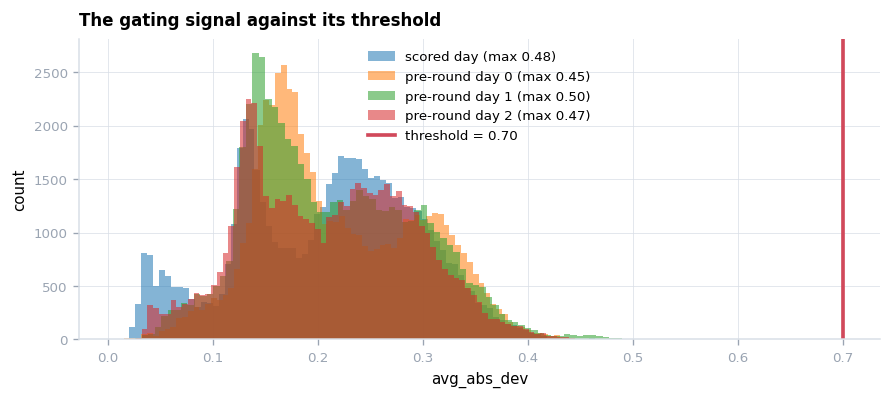

In [8]:
import decision_trace as dt, io, contextlib
vals = {}
for lab, args in [("scored day", None)] + [(f"pre-round day {d}", d) for d in DAYS]:
    if args is None:
        log = pr.load_log("../submissions/round3.log")
        states, dm = dt.rebuild_states(log, "../submissions/datamodel.py")
    else:
        states, dm = dt.rebuild_states_from_csv(
            f"{DATA}/prices_round_3_day_{args}.csv", f"{DATA}/trades_round_3_day_{args}.csv",
            "../submissions/datamodel.py")
    with contextlib.redirect_stdout(io.StringIO()):
        tt = dt.trace("../submissions/round3.py", states, dm, capture=(int, float, bool, str))
    v, reached = [], 0
    for t in tt:
        hit = False
        for ln, s in t.lines:
            if ln == 362 and "avg_abs_dev" in s:
                v.append(s["avg_abs_dev"]); hit = True
        reached += hit
    vals[lab] = np.array(v)
    print(f"{lab:20s} gate reached on {reached:5d} ticks   max {np.max(v):.4f}   "
          f"times above 0.7: {int((np.array(v) >= .7).sum())}")

fig, ax = plt.subplots(figsize=(7.5, 3.4))
for lab, v in vals.items():
    ax.hist(v, bins=80, alpha=.55, label=f"{lab} (max {v.max():.2f})")
ax.axvline(0.7, color=F.HI, lw=2.2, label="threshold = 0.70")
F.finish(ax, "The gating signal against its threshold", "avg_abs_dev", "count", legend=True)
F.save(fig, "r3_threshold")

**The threshold sits 47% above the highest value the signal ever reached**, on the scored day
and on all three pre-round days alike. Roughly 60,000 evaluations, zero passes.

Two things follow.

**It was not a crash.** The option module is wrapped in `try: ... except: pass`, so silence
and failure are indistinguishable from the log. The replay shows line 362 executing on 9,990
of 10,000 ticks — reaching it means no exception was raised. The gate rejected it.

**It was visible before submission.** The same source over the pre-round data sends zero
voucher orders on every day. Printing an order count per product would have exposed it in
under a minute.

## 7. What the bug was worth

Changing only `IV_SCALPING_THR`, nothing else, on the scored day.

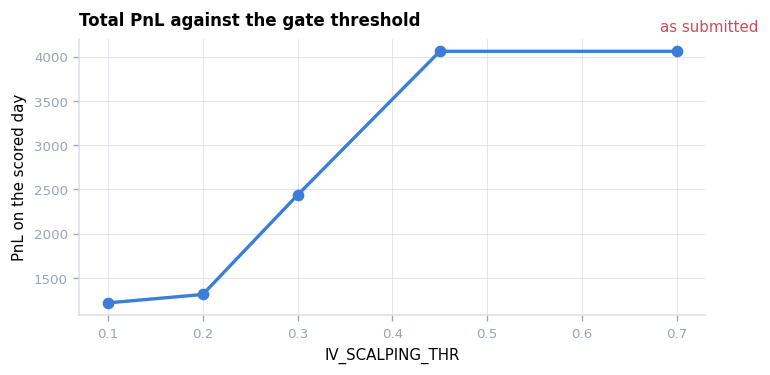

,threshold,voucher PnL,total
0,0.70,0,4060
1,0.45,0,4060
2,0.30,-1622,2438
3,0.20,-2745,1315
4,0.10,-2840,1220


In [9]:
res = {0.7: (0, 4060), 0.45: (0, 4060), 0.30: (-1622, 2438), 0.20: (-2745, 1315), 0.10: (-2840, 1220)}
fig, ax = plt.subplots(figsize=(6.5, 3.2))
th = list(res); tot = [res[t][1] for t in th]
ax.plot(th, tot, "o-", lw=2, ms=6, color=F.BLUE)
ax.annotate("as submitted", (0.7, res[0.7][1]), xytext=(-10, 12),
            textcoords="offset points", color=F.HI, fontsize=9)
F.finish(ax, "Total PnL against the gate threshold", "IV_SCALPING_THR", "PnL on the scored day")
F.save(fig, "r3_threshold_value")
pd.DataFrame([{"threshold": t, "voucher PnL": res[t][0], "total": res[t][1]} for t in th])

**Opening the gate loses money.**

The natural reading of this round — a mis-set threshold silenced the option book and cost the
round — is wrong. The threshold suppressed a strategy that was itself unprofitable, and
because it never ran, that was never discovered.

The two call for different remedies: one is a one-line fix, the other requires discarding the
approach. **Acting on the first diagnosis would have made the round worse.**

*The voucher path has no realised fills to calibrate the simulator against, so only the sign
and ordering here should be relied on. The direction is consistent across all thresholds
tested.*

## 8. Where the round was actually lost

The rank-96 team's Round 3 submission, run on the same day in the same simulator:

| | PACK | FRUIT | vouchers | total |
|---|---:|---:|---:|---:|
| mine | 7,090 | −3,030 | **0** | 4,060 |
| rank 96 | **20,848** | **13,238** | **−10,731** | 23,355 |

**Their voucher book lost more than mine, which did nothing.** Their entire advantage came
from the two spot instruments — the two products §5 shows are worth 4,573 and 1,672 a day
against 2,104 for all ten vouchers combined.

The round was not lost on options. It was lost by spending the effort there.